In [ ]:
import json
import pandas as pd

# Suggestions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

file_path = '/content/suggestion_metrics_data.json'
with open(file_path, 'r') as file:
    data = json.load(file)

df_suggestions = pd.DataFrame(data)

df_suggestions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7717 entries, 0 to 7716
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   suggestion_id      7717 non-null   int64  
 1   developer_id       7717 non-null   object 
 2   session_id         7717 non-null   object 
 3   timestamp          7717 non-null   object 
 4   accepted           7717 non-null   int64  
 5   decision_time_sec  7717 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 361.9+ KB


In [ ]:
threshold = 0.3

In [ ]:
df_suggestions['timestamp'] = pd.to_datetime(df_suggestions['timestamp'])

df_suggestions = df_suggestions[(df_suggestions['accepted'].notnull())]

filtered_suggestions = df_suggestions[
    (df_suggestions['decision_time_sec'].notna()) &
    (df_suggestions['decision_time_sec'] < threshold)
].copy()

print(f"Number of suggestions with decision_time_sec < {threshold}: {filtered_suggestions.shape[0]}")

Number of suggestions with decision_time_sec < 0.3: 469


In [ ]:
df_suggestions.shape

(7717, 6)

Phase 1: 453 fast out of 5460 total suggestions (8.30%)
Phase 2: 13 fast out of 1428 total suggestions (0.91%)
Phase 3: 3 fast out of 829 total suggestions (0.36%)


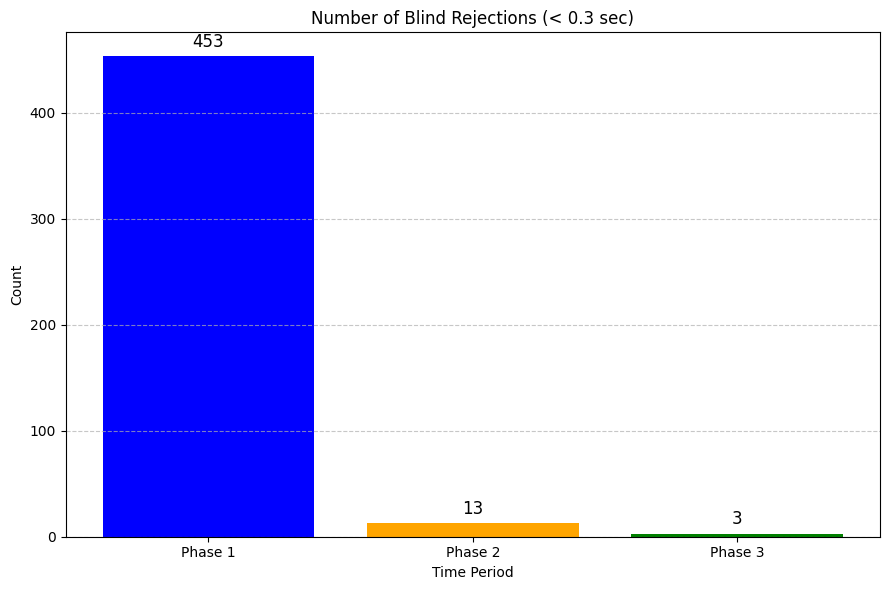

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

cutoff_1 = '2025-03-03 00:00:01'
cutoff_2 = '2025-04-04 23:59:59'

before_all = df_suggestions[
    (df_suggestions['timestamp'] <= cutoff_1) &
    (df_suggestions['accepted'].notnull())
]
before_fast = before_all[
    (before_all['decision_time_sec'].notna()) &
    (before_all['decision_time_sec'] < threshold)
]

mid_all = df_suggestions[
    (df_suggestions['timestamp'] > cutoff_1) &
    (df_suggestions['timestamp'] < cutoff_2) &
    (df_suggestions['accepted'].notnull())
]
mid_fast = mid_all[
    (mid_all['decision_time_sec'].notna()) &
    (mid_all['decision_time_sec'] < threshold)
]

after_all = df_suggestions[
    (df_suggestions['timestamp'] > cutoff_2) &
    (df_suggestions['accepted'].notnull())
]
after_fast = after_all[
    (after_all['decision_time_sec'].notna()) &
    (after_all['decision_time_sec'] < threshold)
]

counts = [before_fast.shape[0], mid_fast.shape[0], after_fast.shape[0]]
totals = [before_all.shape[0], mid_all.shape[0], after_all.shape[0]]
ratios = [count / total * 100 if total > 0 else 0 for count, total in zip(counts, totals)]

labels = ['Phase 1', 'Phase 2', 'Phase 3']

for label, count, total, ratio in zip(labels, counts, totals, ratios):
    print(f"{label}: {count} fast out of {total} total suggestions ({ratio:.2f}%)")


import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.bar(labels, counts, color=['blue', 'orange', 'green'])
plt.title(f'Number of Blind Rejections (< {threshold} sec)')
plt.ylabel('Count')
plt.xlabel('Time Period')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

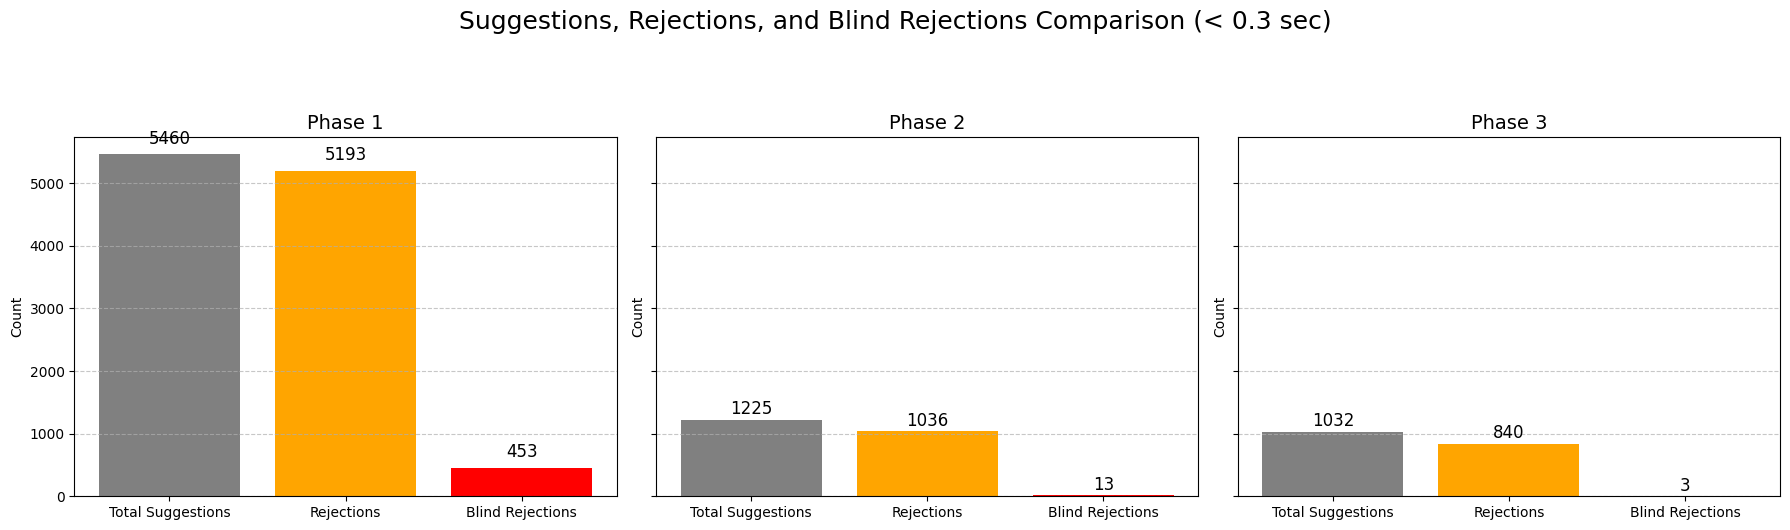

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- cutoff dates ---
cutoff_1 = '2025-03-03 00:00:01'
cutoff_2 = '2025-04-03 23:59:59'

before_all = df_suggestions[
    (df_suggestions['timestamp'] <= cutoff_1) &
    (df_suggestions['accepted'].notnull())
]

mid_all = df_suggestions[
    (df_suggestions['timestamp'] > cutoff_1) &
    (df_suggestions['timestamp'] < cutoff_2) &
    (df_suggestions['accepted'].notnull())
]

after_all = df_suggestions[
    (df_suggestions['timestamp'] >= cutoff_2) &
    (df_suggestions['accepted'].notnull())
]

def compute_counts(df):
    total = df.shape[0]
    rejected = df[df['accepted'] == 0].shape[0]
    blind_rejected = df[
        (df['decision_time_sec'].notna()) &
        (df['decision_time_sec'] < threshold)
    ].shape[0]
    return total, rejected, blind_rejected

before_counts = compute_counts(before_all)
mid_counts = compute_counts(mid_all)
after_counts = compute_counts(after_all)

bar_labels = ['Total Suggestions', 'Rejections', 'Blind Rejections']
phase_titles = ['Phase 1', 'Phase 2', 'Phase 3']
phase_counts = [before_counts, mid_counts, after_counts]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, title, counts in zip(axes, phase_titles, phase_counts):
    ax.bar(bar_labels, counts, color=['grey', 'orange', 'red'])
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    for i, count in enumerate(counts):
        ax.text(i, count + max(counts)*0.02, str(count), ha='center', va='bottom', fontsize=12)

fig.suptitle(f'Suggestions, Rejections, and Blind Rejections Comparison (< {threshold} sec)', fontsize=18, y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


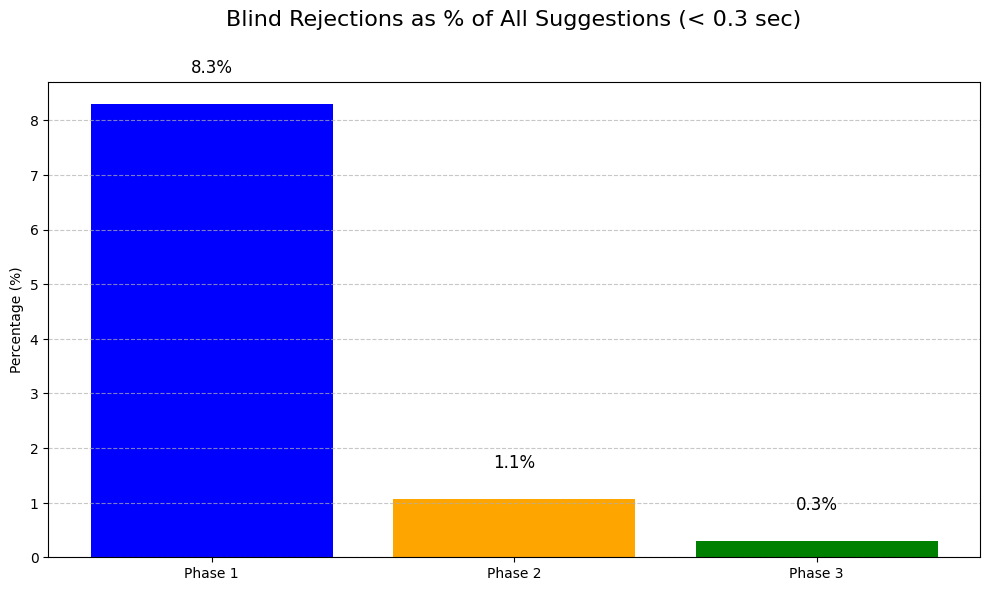

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- cutoff dates ---
cutoff_1 = '2025-03-03 00:00:01'
cutoff_2 = '2025-04-03 23:59:59'

before_all = df_suggestions[
    (df_suggestions['timestamp'] <= cutoff_1) &
    (df_suggestions['accepted'].notnull())
]

mid_all = df_suggestions[
    (df_suggestions['timestamp'] > cutoff_1) &
    (df_suggestions['timestamp'] < cutoff_2) &
    (df_suggestions['accepted'].notnull())
]

after_all = df_suggestions[
    (df_suggestions['timestamp'] >= cutoff_2) &
    (df_suggestions['accepted'].notnull())
]

def compute_blind_ratio(df):
    total = df.shape[0]
    blind_rejected = df[
        (df['decision_time_sec'].notna()) &
        (df['decision_time_sec'] < threshold)
    ].shape[0]
    return blind_rejected / total * 100 if total > 0 else 0

before_blind = compute_blind_ratio(before_all)
mid_blind = compute_blind_ratio(mid_all)
after_blind = compute_blind_ratio(after_all)

labels = ['Phase 1', 'Phase 2', 'Phase 3']
ratios = [before_blind, mid_blind, after_blind]

plt.figure(figsize=(10, 6))
plt.bar(labels, ratios, color=['blue', 'orange', 'green'])
plt.title(f'Blind Rejections as % of All Suggestions (< {threshold} sec)', fontsize=16, y=1.1)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, ratio in enumerate(ratios):
    plt.text(i, ratio + 0.5, f"{ratio:.1f}%", ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()


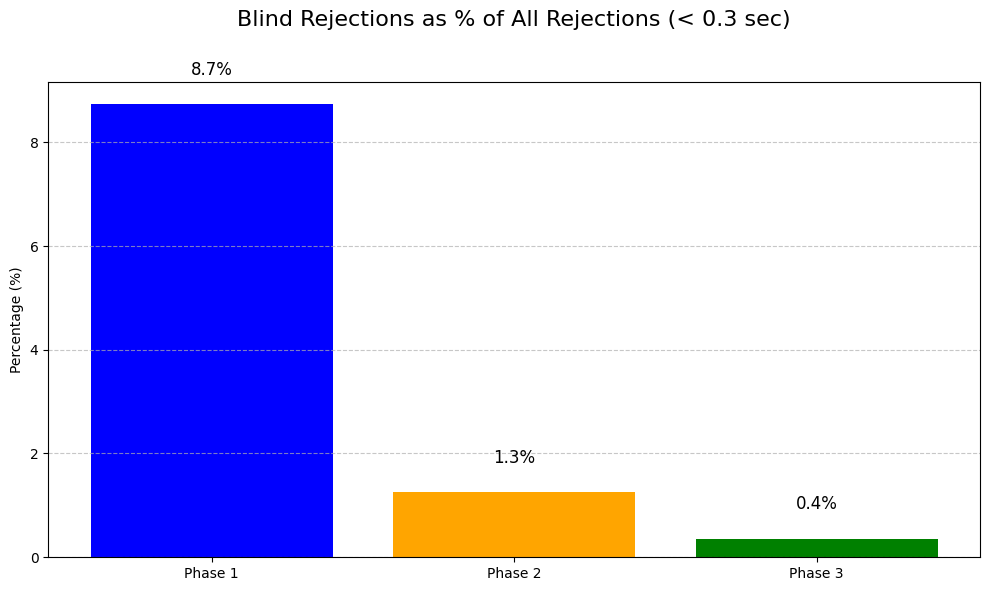

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- cutoff dates ---
cutoff_1 = '2025-03-03 00:00:01'
cutoff_2 = '2025-04-03 23:59:59'

before_all = df_suggestions[
    (df_suggestions['timestamp'] < cutoff_1) &
    (df_suggestions['accepted'].notnull())
]
mid_all = df_suggestions[
    (df_suggestions['timestamp'] >= cutoff_1) &
    (df_suggestions['timestamp'] <= cutoff_2) &
    (df_suggestions['accepted'].notnull())
]
after_all = df_suggestions[
    (df_suggestions['timestamp'] > cutoff_2) &
    (df_suggestions['accepted'].notnull())
]

def compute_blind_ratio(df):
    rejected = df[df['accepted'] == 0].shape[0]
    blind = df[
        (df['decision_time_sec'].notna()) &
        (df['decision_time_sec'] < threshold)
    ].shape[0]
    return blind / rejected * 100 if rejected > 0 else 0

before_ratio = compute_blind_ratio(before_all)
mid_ratio = compute_blind_ratio(mid_all)
after_ratio = compute_blind_ratio(after_all)

labels = ['Phase 1', 'Phase 2', 'Phase 3']
ratios = [before_ratio, mid_ratio, after_ratio]

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.bar(labels, ratios, color=['blue', 'orange', 'green'])
plt.title(f'Blind Rejections as % of All Rejections (< {threshold} sec)', fontsize=16, y=1.1)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, ratio in enumerate(ratios):
    plt.text(i, ratio + 0.5, f"{ratio:.1f}%", ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()


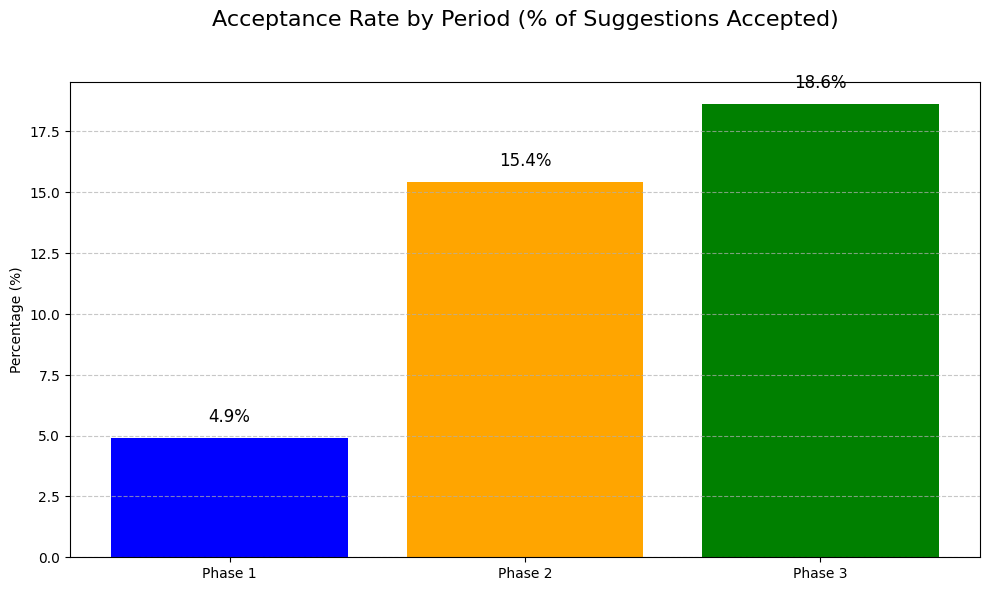

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- cutoff dates ---
cutoff_1 = '2025-03-03 00:00:01'
cutoff_2 = '2025-04-03 23:59:59'

before_all = df_suggestions[
    (df_suggestions['timestamp'] < cutoff_1) &
    (df_suggestions['accepted'].notnull())
]

mid_all = df_suggestions[
    (df_suggestions['timestamp'] >= cutoff_1) &
    (df_suggestions['timestamp'] <= cutoff_2) &
    (df_suggestions['accepted'].notnull())
]

after_all = df_suggestions[
    (df_suggestions['timestamp'] > cutoff_2) &
    (df_suggestions['accepted'].notnull())
]

# --- Compute acceptance rate ---
def compute_acceptance_rate(df):
    total = df.shape[0]
    accepted = df[df['accepted'] == 1].shape[0]
    return accepted / total * 100 if total > 0 else 0

before_accept = compute_acceptance_rate(before_all)
mid_accept = compute_acceptance_rate(mid_all)
after_accept = compute_acceptance_rate(after_all)

labels = ['Phase 1', 'Phase 2', 'Phase 3']
ratios = [before_accept, mid_accept, after_accept]

plt.figure(figsize=(10, 6))
plt.bar(labels, ratios, color=['blue', 'orange', 'green'])
plt.title('Acceptance Rate by Period (% of Suggestions Accepted)', fontsize=16, y=1.1)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, ratio in enumerate(ratios):
    plt.text(i, ratio + 0.5, f"{ratio:.1f}%", ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()


#Statistical Testing

In [ ]:
for n,k in [(5460,267),(1225,189),(1032,192)]:
    p=k/n
    se=(p*(1-p)/n)**0.5
    ci=(p-1.96*se, p+1.96*se)
    print(f"{p*100:.2f}%  SE={se*100:.2f}%  CI=[{ci[0]*100:.1f}, {ci[1]*100:.1f}]")

4.89%  SE=0.29%  CI=[4.3, 5.5]
15.43%  SE=1.03%  CI=[13.4, 17.5]
18.60%  SE=1.21%  CI=[16.2, 21.0]


In [ ]:
import mpmath as mp

In [ ]:
import math
def p_value(z):
    return math.erfc(abs(z)/math.sqrt(2))
def two_prop(k1,n1,k2,n2):
    p1=k1/n1; p2=k2/n2
    p_hat=(k1+k2)/(n1+n2)
    se=math.sqrt(p_hat*(1-p_hat)*(1/n1+1/n2))
    z=(p1-p2)/se
    return p1,p2,z,p_value(z)

In [ ]:
blind1=453
rej1=5193
blind2=13
rej2=1036
blind3=3
rej3=840
print(blind1/rej1, blind1/5460)
print(blind2/rej2, blind2/1225)
print(blind3/rej3, blind3/1032)

0.08723281340265743 0.08296703296703296
0.012548262548262547 0.010612244897959184
0.0035714285714285713 0.0029069767441860465


In [ ]:
def ratio_test(blind1,rej1,blind2,rej2):
    # proportion of blind among rejections
    n1=rej1
    k1=blind1
    n2=rej2
    k2=blind2
    return two_prop(k1,n1,k2,n2)
print("Blind ratio rejections: Phase1 vs Phase2", ratio_test(blind1,rej1,blind2,rej2))
print("Blind ratio Phase2 vs Phase3", ratio_test(blind2,rej2,blind3,rej3))

Blind ratio rejections: Phase1 vs Phase2 (0.08723281340265743, 0.012548262548262547, 8.342797644270393, 7.255325920480115e-17)
Blind ratio Phase2 vs Phase3 (0.012548262548262547, 0.0035714285714285713, 2.102532257039566, 0.03550667705119074)


In [ ]:
for phase,(n,k) in enumerate([(5460,267),(1225,189),(1032,192)],1):
    print(phase, n/k)

1 20.44943820224719
2 6.481481481481482
3 5.375
